In [2]:
import pandas as pd

# Load both datasets
df1 = pd.read_csv("delhi_msw_70_percent.csv")   # 70% collected
df2 = pd.read_csv("delhi_msw_90_percent.csv")   # 90% collected

# Combine them
df = pd.concat([df1, df2], ignore_index=True)

print(df.head())

             Zone  Waste Generated (TPD)  Waste Collected (TPD)  \
0  North Shahdara                   1250                    875   
1  South Shahdara                   1200                    840   
2         Central                   1000                    700   
3         City SP                    950                    665   
4          Rohini                    950                    665   

  Population (approx.)  
0           20.36 lakh  
1           20.06 lakh  
2           15.84 lakh  
3            6.05 lakh  
4           20.17 lakh  


In [6]:
print(df.columns)

Index(['Zone', 'Waste Generated (TPD)', 'Waste Collected (TPD)',
       'Population (approx.)'],
      dtype='object')


In [7]:
df["Efficiency"] = df["Waste Collected (TPD)"] / df["Waste Generated (TPD)"]

In [13]:
df["Population (approx.)"] = df["Population (approx.)"].str.replace("lakh", "")
df["Population (approx.)"] = df["Population (approx.)"].str.strip()

In [16]:
def convert_population(value):
    value = str(value).lower().strip()
    
    # remove symbols like ~
    value = value.replace("~", "")
    
    if "lakh" in value:
        num = float(value.replace("lakh", "").strip())
        return num * 100000
    
    elif "crore" in value:
        num = float(value.replace("crore", "").strip())
        return num * 10000000
    
    else:
        return float(value)

# apply function
df["Population"] = df["Population (approx.)"].apply(convert_population)


In [19]:
df = df[df["Zone"] != "Total MCD"]

In [20]:
X = df[["Efficiency", "Population"]]

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=0)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df[["Zone", "Cluster"]])

              Zone  Cluster
0   North Shahdara        1
1   South Shahdara        1
2          Central        1
3          City SP        1
4           Rohini        1
5        Najafgarh        1
6            South        1
7             West        1
8       Karol Bagh        1
9      Civil Lines        1
10    Keshav Puram        1
11          Narela        1
13  North Shahdara        0
14  South Shahdara        0
15         Central        0
16         City SP        0
17          Rohini        0
18       Najafgarh        0
19           South        0
20            West        0
21      Karol Bagh        0
22     Civil Lines        0
23    Keshav Puram        0
24          Narela        0


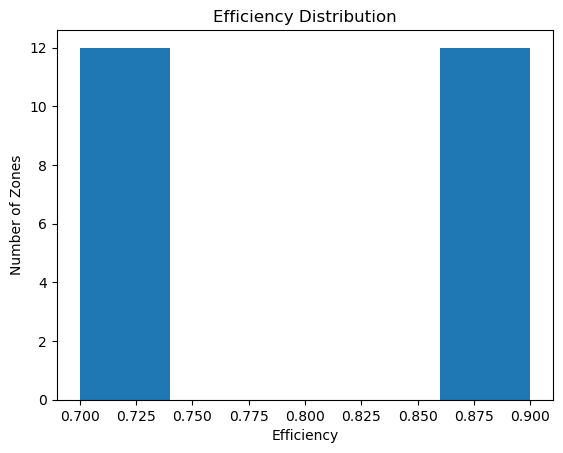

In [21]:
import matplotlib.pyplot as plt

plt.hist(df["Efficiency"], bins=5)
plt.title("Efficiency Distribution")
plt.xlabel("Efficiency")
plt.ylabel("Number of Zones")
plt.show()

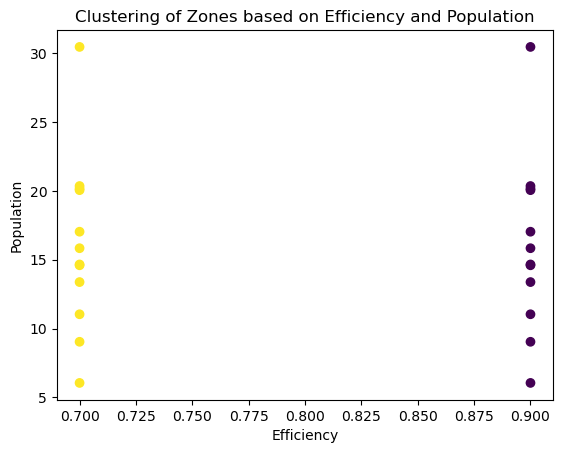

In [22]:
plt.scatter(df["Efficiency"], df["Population"], c=df["Cluster"])
plt.xlabel("Efficiency")
plt.ylabel("Population")
plt.title("Clustering of Zones based on Efficiency and Population")
plt.show()

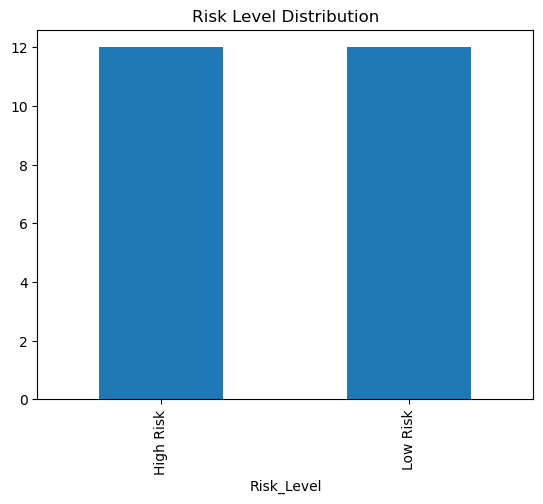

In [24]:
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()